In [ ]:
# STAGE 1 — Load data

import pandas as pd

df = pd.read_csv("fakenews.csv")

# Keep only useful columns
df = df[['text', 'label']]

# Keep only valid labels
df['label'] = df['label'].astype(str).str.strip()
df = df[df['label'].isin(['0', '1'])]

df['label'] = df['label'].astype(int)

df.head()

/tmp/ipykernel_14127/3076517732.py:5: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

,text,label
0,Get the latest from TODAY Sign up for our news...,1
1,2d Conan On The Funeral Trump Will Be Invited...,1
2,It’s safe to say that Instagram Stories has fa...,0
3,Much like a certain Amazon goddess with a lass...,0
4,At a time when the perfect outfit is just one ...,0


This initial code block loads the `fakenews.csv` dataset into a pandas DataFrame. It then performs essential preprocessing steps:
- Selects only the `text` and `label` columns.
- Converts the `label` column to string, strips whitespace, and filters to keep only rows where the label is '0' or '1'.
- Finally, it converts the `label` column to an integer type and displays the first few rows of the cleaned DataFrame.

In [ ]:
# STAGE 2 — Raw documents

print(df.shape)
print(df['label'].value_counts())
print(df['text'].iloc[0][:500])

(4896, 2)
label
0    2925
1    1971
Name: count, dtype: int64
Get the latest from TODAY Sign up for our newsletter  No one ever truly gets over losing a loved one, and Blake Shelton is no exception. He was just 14 when his older brother Richie died on Nov. 13, 1990. And, as Shelton noted in a tweet Monday, "It changed my life forever."  Richie was 24 when he died in a car accident in the Sheltons' home state of Oklahoma. Two years ago, Shelton sent out a message for the 25th anniversary of his loss:  Richie, who was Blake's half-brother (they shared a moth


This block provides a raw overview of the dataset after initial loading:
- It prints the shape of the DataFrame, showing the number of rows and columns.
- It displays the value counts for the `label` column, indicating the distribution of '0' (real news) and '1' (fake news) entries.
- It also shows the first 500 characters of the first document's text to give an idea of the raw content.

In [ ]:
# STAGE 3 — Tokenisation + cleaning

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

This stage focuses on text cleaning. A `clean_text` function is defined and applied to the `text` column to create a new `clean_text` column. The cleaning steps include:
- Converting all text to lowercase.
- Removing URLs.
- Removing any characters that are not lowercase English letters or spaces.
- Reducing multiple spaces to single spaces and stripping leading/trailing whitespace.

In [ ]:
# STAGE 4 — Stop words + stemming

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def process_text(text):
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    stems = [stemmer.stem(w) for w in tokens]
    return " ".join(stems)

df['processed_text'] = df['clean_text'].apply(process_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Here, we perform further text preprocessing by removing stop words and applying stemming.
- NLTK's `stopwords` and `PorterStemmer` are used.
- The `process_text` function tokenizes the clean text, removes common English stop words, filters out short words (length less than 3), and then stems the remaining words to their root form.
- A new `processed_text` column is created containing the results of this process.

In [ ]:
# STAGE 5 — Document-Term Matrix

from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(max_features=1000)
dtm = count_vectorizer.fit_transform(df['processed_text'])

dtm_df = pd.DataFrame(
    dtm.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

dtm_df.head()

,abc,abl,absolut,abus,academi,accept,accord,account,accus,across,...,write,writer,written,wrong,wrote,ye,year,yet,york,young
0,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,2,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,2,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,2,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


This block creates a Document-Term Matrix (DTM) using `CountVectorizer`.
- It converts the `processed_text` into a matrix where each row represents a document and each column represents a word from the vocabulary, with values indicating the frequency of that word in the document.
- `max_features=1000` limits the vocabulary to the 1000 most frequent words.
- The resulting DTM is converted into a pandas DataFrame (`dtm_df`) for easier inspection, and its head is displayed.

In [ ]:
# STAGE 6 — TF-IDF vectors

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df['processed_text'])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,abc,abl,absolut,abus,academi,accept,accord,account,accus,act,...,worth,write,writer,written,wrong,wrote,ye,year,york,young
0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.046671,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.05338,0.0,0.057732,0.055398,0.000000
1,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.000000
2,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.068682,0.0,0.0,0.0,0.0,0.00000,0.0,0.026353,0.000000,0.000000
3,0.0,0.042165,0.0,0.0,0.027731,0.0,0.015306,0.0,0.0,0.019935,...,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.018933,0.000000,0.020212
4,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.081770,0.000000,0.000000


This stage generates TF-IDF (Term Frequency-Inverse Document Frequency) vectors.
- `TfidfVectorizer` is used to convert the `processed_text` into a matrix where the values reflect the importance of a word in a document relative to the entire corpus.
- Similar to the DTM, `max_features=1000` is applied.
- The TF-IDF matrix (`X_tfidf`) is then converted into a pandas DataFrame (`tfidf_df`), and its head is displayed. TF-IDF is often more effective than raw counts for text classification as it down-weights common words.

In [ ]:
# STAGE 7 — Key terms

terms = tfidf.get_feature_names_out()

for i in range(5):
    row = X_tfidf[i].toarray().flatten()
    top_terms = row.argsort()[-10:][::-1]

    print(f"Document {i}")
    print([terms[j] for j in top_terms])
    print()

Document 0
['blake', 'shelton', 'brother', 'die', 'dead', 'car', 'phone', 'pick', 'guy', 'citi']

Document 1
['invit', 'trump', 'forward', 'form', 'forc', 'food', 'follow', 'focus', 'focu', 'fit']

Document 2
['stori', 'instagram', 'fashion', 'watch', 'scene', 'busi', 'prepar', 'home', 'design', 'celebr']

Document 3
['woman', 'wonder', 'say', 'think', 'movi', 'director', 'women', 'film', 'direct', 'talk']

Document 4
['brand', 'hurt', 'ahead', 'click', 'organ', 'commit', 'industri', 'process', 'problem', 'design']



This section demonstrates how to identify the most significant terms within individual documents based on their TF-IDF scores.
- For the first 5 documents, it retrieves the terms with the highest TF-IDF values.
- The output shows a list of the top 10 most important words for each of these documents, providing insights into their content.

In [ ]:
# STAGE 8 — Sentiment scoring

nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

df[['label', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,label,sentiment
0,1,-0.5719
1,1,-0.3612
2,0,0.9863
3,0,0.9993
4,0,0.7147


Here, sentiment analysis is performed using NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner).
- The `vader_lexicon` is downloaded, and a `SentimentIntensityAnalyzer` is initialized.
- For each document's `clean_text`, VADER calculates a `compound` sentiment score, which is a normalized, weighted composite score ranging from -1 (most negative) to +1 (most positive).
- A new `sentiment` column is added to the DataFrame, and the head of the `label` and `sentiment` columns is displayed.

In [ ]:
# STAGE 9 — Compare spam vs normal

sentiment_result = df.groupby('label')['sentiment'].mean()
print(sentiment_result)

label
0    0.547960
1    0.465765
Name: sentiment, dtype: float64


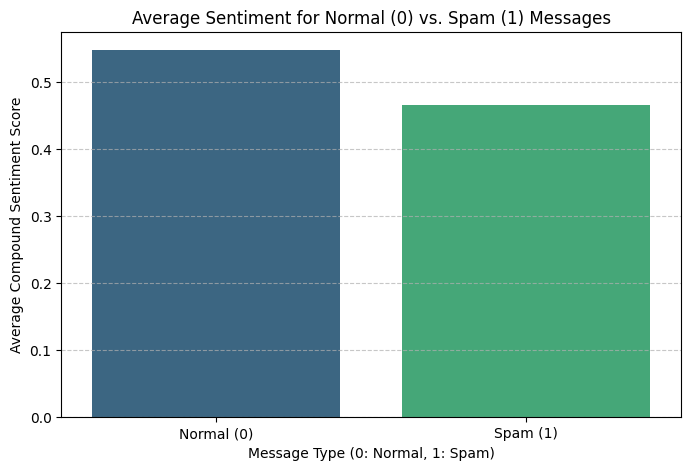

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming sentiment_result is already calculated as shown in F5yGJnpOszXM
# If not, re-calculate it:
sentiment_result = df.groupby('label')['sentiment'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_result.index, y=sentiment_result.values, hue=sentiment_result.index, palette='viridis', legend=False)
plt.title('Average Sentiment for Normal (0) vs. Spam (1) Messages')
plt.xlabel('Message Type (0: Normal, 1: Spam)')
plt.ylabel('Average Compound Sentiment Score')
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Spam (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

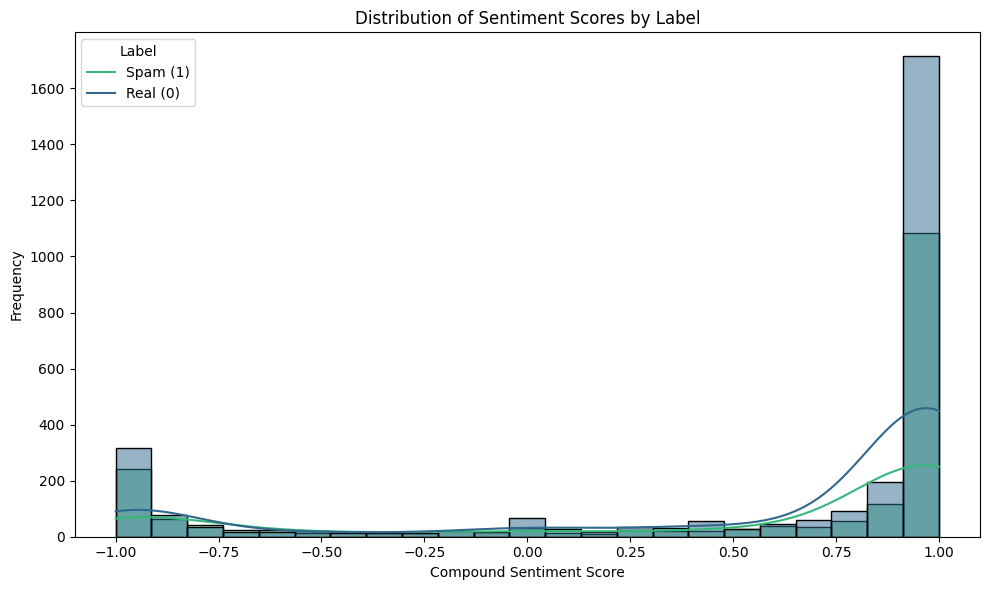

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms for sentiment scores, separated by label
sns.histplot(data=df, x='sentiment', hue='label', kde=True, ax=ax, palette='viridis')

# Add titles and labels
ax.set_title('Distribution of Sentiment Scores by Label')
ax.set_xlabel('Compound Sentiment Score')
ax.set_ylabel('Frequency')

# Show the legend
ax.legend(title='Label', labels=['Spam (1)', 'Real (0)'])

plt.tight_layout()
plt.show()

This block compares the average sentiment scores between the two `label` categories (0 and 1).
- It groups the DataFrame by the `label` column and calculates the mean `sentiment` for each group.
- The `sentiment_result` shows that there's a slight difference in average sentiment between documents labeled '0' and '1', with '0' having a slightly higher positive average sentiment.

This block generates a histogram to visualize the distribution of sentiment scores, separated by the 'label' (fake or real news). It helps to observe if there are distinct sentiment patterns between the two categories.

This block calculates and visualizes the average sentiment for each topic, further broken down by the news label. This bar plot helps in understanding the emotional tone associated with specific topics within both real and fake news categories, assuming a 'topic' column was previously created in the DataFrame.

In [ ]:
# STAGE 10 — Topic modelling with LDA

from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

topic_matrix = lda.fit_transform(X_tfidf)

df['topic'] = topic_matrix.argmax(axis=1)

# Print topics

for topic_id, topic in enumerate(lda.components_):
    top_words = topic.argsort()[-10:][::-1]
    print(f"Topic {topic_id}")
    print([terms[i] for i in top_words])
    print()

Topic 0
['meghan', 'harri', 'princ', 'royal', 'markl', 'kate', 'shelton', 'wed', 'blake', 'gwen']

Topic 1
['year', 'kardashian', 'like', 'love', 'said', 'time', 'share', 'babi', 'photo', 'want']

Topic 2
['season', 'film', 'said', 'year', 'new', 'seri', 'star', 'time', 'perform', 'award']

Topic 3
['brad', 'pitt', 'joli', 'jen', 'angelina', 'aniston', 'jennif', 'justin', 'sourc', 'theroux']

Topic 4
['trump', 'presid', 'state', 'obama', 'donald', 'said', 'peopl', 'nation', 'white', 'american']



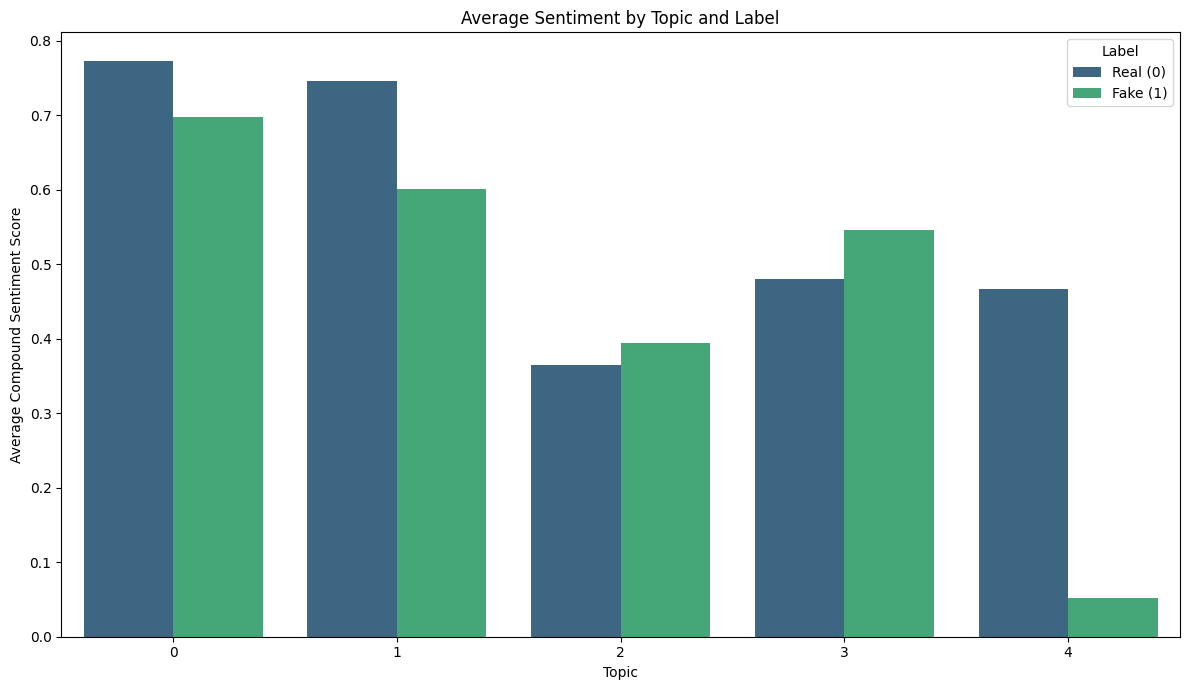

<Figure size 1000x600 with 0 Axes>

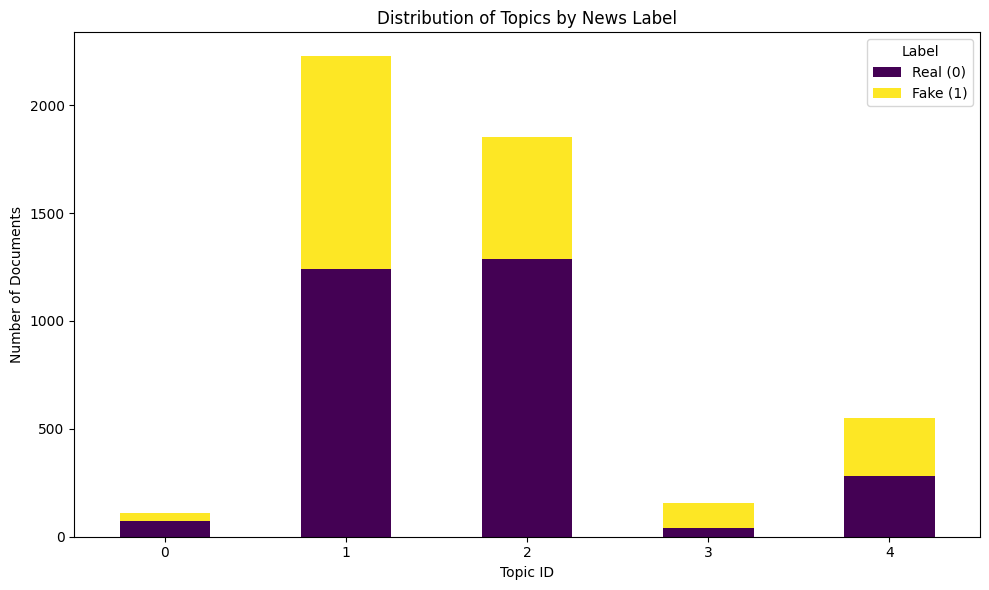

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average sentiment for each topic and label combination
average_sentiment_by_topic_label = df.groupby(['topic', 'label'])['sentiment'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=average_sentiment_by_topic_label, x='topic', y='sentiment', hue='label', palette='viridis')

# Add titles and labels
plt.title('Average Sentiment by Topic and Label')
plt.xlabel('Topic')
plt.ylabel('Average Compound Sentiment Score')
plt.xticks(rotation=0)

# Adjust legend for clarity
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Real (0)', 'Fake (1)'], title='Label')

plt.tight_layout()
plt.show()

# Define topic_label_table before using it
topic_label_table = pd.crosstab(df['topic'], df['label'])

# Plotting the distribution of topics across labels
plt.figure(figsize=(10, 6))
topic_label_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Distribution of Topics by News Label')
plt.xlabel('Topic ID')
plt.ylabel('Number of Documents')
plt.xticks(rotation=0)
plt.legend(title='Label', labels=['Real (0)', 'Fake (1)'])
plt.tight_layout()
plt.show()

This block generates two visualizations:  
- The first plot displays the average sentiment for each topic, broken down by the news label (real or fake). This helps to understand the emotional tone associated with specific topics within both real and fake news categories.
- The second plot is a stacked bar chart illustrating the distribution of documents across the discovered topics and their original 'label' (fake or real news). This helps to understand if certain topics are more prevalent in either fake or real news categories.

This stage performs Topic Modeling using Latent Dirichlet Allocation (LDA) on the TF-IDF vectors.
- An LDA model is initialized with `n_components=5`, aiming to discover 5 underlying topics in the dataset.
- `fit_transform` applies LDA to the TF-IDF matrix, yielding a `topic_matrix` where each row indicates the probability of a document belonging to each topic.
- The `topic` with the highest probability for each document is assigned to a new `df['topic']` column.
- Finally, for each of the 5 discovered topics, the top 10 most representative words are printed, giving an interpretation of what each topic is about.

In [ ]:
# STAGE 11 — Link topics to spam / not-spam

topic_label_table = pd.crosstab(df['topic'], df['label'])
print(topic_label_table)

label     0    1
topic           
0        75   36
1      1240  986
2      1286  567
3        41  114
4       283  268


This code block creates a cross-tabulation (contingency table) to show the distribution of documents across the discovered topics and their original 'label' (fake or real news).
- `pd.crosstab` is used to count the occurrences of each topic for both labels.
- The output `topic_label_table` helps to understand if certain topics are more prevalent in either fake or real news categories.

In [ ]:
for k in [3, 5, 7, 10]:
    lda = LatentDirichletAllocation(n_components=k, random_state=42)
    lda.fit(X_tfidf)

    print(f"\n{k} topics")
    for topic_id, topic in enumerate(lda.components_):
        top_words = topic.argsort()[-8:][::-1]
        print(topic_id, [terms[i] for i in top_words])


3 topics
0 ['harri', 'princ', 'meghan', 'royal', 'markl', 'kate', 'wed', 'william']
1 ['kardashian', 'like', 'year', 'love', 'share', 'time', 'babi', 'photo']
2 ['said', 'season', 'trump', 'film', 'year', 'new', 'award', 'time']

5 topics
0 ['meghan', 'harri', 'princ', 'royal', 'markl', 'kate', 'shelton', 'wed']
1 ['year', 'kardashian', 'like', 'love', 'said', 'time', 'share', 'babi']
2 ['season', 'film', 'said', 'year', 'new', 'seri', 'star', 'time']
3 ['brad', 'pitt', 'joli', 'jen', 'angelina', 'aniston', 'jennif', 'justin']
4 ['trump', 'presid', 'state', 'obama', 'donald', 'said', 'peopl', 'nation']

7 topics
0 ['weinstein', 'sexual', 'harvey', 'alleg', 'assault', 'harass', 'accus', 'women']
1 ['year', 'said', 'like', 'love', 'time', 'say', 'want', 'peopl']
2 ['season', 'film', 'award', 'seri', 'new', 'selena', 'star', 'music']
3 ['brad', 'pitt', 'joli', 'angelina', 'aniston', 'jen', 'jennif', 'theroux']
4 ['trump', 'presid', 'state', 'said', 'donald', 'obama', 'offic', 'polic']
5 

This final block explores the effect of choosing a different number of topics for the LDA model.
- It iterates through different values for `n_components` (3, 5, 7, and 10).
- For each `n_components` value, it trains a new LDA model and prints the top 8 words for each of the discovered topics.
- This helps in assessing how the topic coherence and interpretability change with a varying number of topics.